# Data Splitting

## Import libraries

In [29]:
import pandas as pd
import numpy as np
import seaborn as sns

## Import Original Dataset

In [30]:
df = pd.read_csv("..//data//biomass_model_dataset.csv")
df.head()

,SPCD,DO_BH,HT_TOT,TT_DW_CRM
0,12,7.5,45.2,178.86
1,12,9.3,62.7,323.46
2,12,9.7,56.7,342.47
3,12,11.4,66.1,499.35
4,12,6.4,51.8,113.92


In [31]:
df.shape

(137079, 4)

## Generate Histograms of Features/Target to Understand Distribution

array([[<Axes: title={'center': 'DO_BH'}>]], dtype=object)

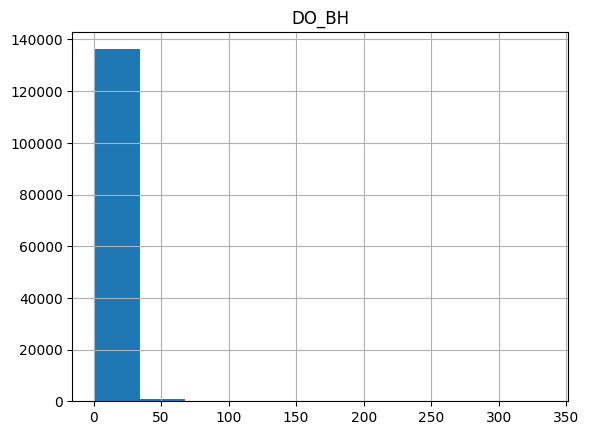

In [23]:
df.hist('DO_BH')

array([[<Axes: title={'center': 'HT_TOT'}>]], dtype=object)

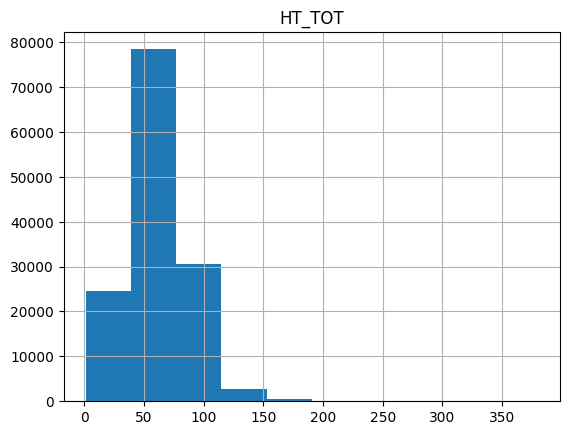

In [24]:
df.hist('HT_TOT')

array([[<Axes: title={'center': 'TT_DW_CRM'}>]], dtype=object)

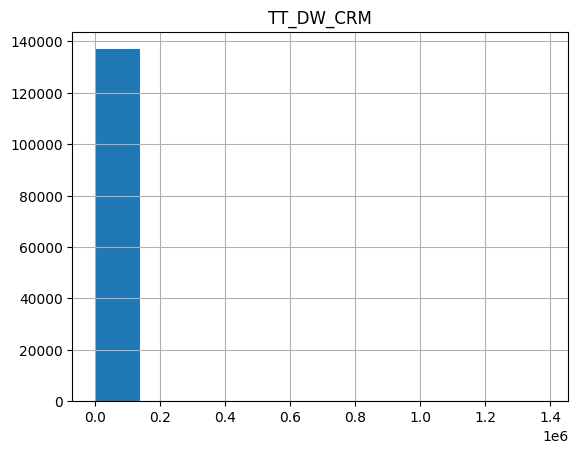

In [26]:
df.hist('TT_DW_CRM')

## Shuffle Data, Split Into Training, Validating, Testing Datasets

### Rename columns for better readability

In [32]:
df.rename(columns={"SPCD": "Species", "DO_BH": "Breast_Diameter", "HT_TOT": "Total_Height", "TT_DW_CRM": "Target_Biomass"})

,Species,Breast_Diameter,Total_Height,Target_Biomass
0,12,7.5,45.2,178.86
1,12,9.3,62.7,323.46
2,12,9.7,56.7,342.47
3,12,11.4,66.1,499.35
4,12,6.4,51.8,113.92
...,...,...,...,...
137074,922,2.5,24.8,15.98
137075,922,3.7,23.7,40.62
137076,922,2.9,30.9,22.74
137077,922,5.6,40.0,87.79


### Get Value Counts per Species, Delete rows associated with rarely observed species

In [33]:
pd.set_option('display.max_rows', 20)
df.value_counts(df.SPCD)

SPCD
131     20140
111      8006
202      7322
122      5609
110      5599
        ...  
8211        1
8558        1
8597        1
8715        1
8768        1
Name: count, Length: 230, dtype: int64

### Decided to include all species, will be filtering testing point by species before distance is calculated. We also want to introduce weights per each individual dimension

In [ ]:
# Randomly split data into training/validating/testing 

shuffled = df.sample(frac=1, random_state=42)  # Shuffle the data with a fixed random state for reproducibility
result = np.array_split(shuffled, 3)

datasets = ['train', 'validate', 'test']
splits = {}

for name, split in zip(datasets, result):
    splits[name] = split

df_train = splits['train']
df_valid = splits['validate']
df_test = splits['test']      


c:\Users\wolfe\OneDrive\Desktop\311-projects\venv\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [9]:
df_train.shape

(45693, 4)

In [10]:
df_valid.shape

(45693, 4)

In [11]:
df_test.shape

(45693, 4)

In [34]:
df_train.to_csv("..//data//train_biomass.csv")

In [35]:
df_valid.to_csv("..//data//validate_biomass.csv")

In [36]:
df_test.to_csv("..//data//test_biomass.csv")